In [1]:
import os
import sys

os.chdir("..")

In [2]:
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from torch import nn
from tqdm.auto import tqdm
from lightning_fabric import seed_everything
from sklearn.decomposition import PCA
from umap import UMAP
import warnings

from gjepa.models.gjepa_model import GJEPANodeModel
from gjepa.models.node_model import SupervisedNodeLevelGNN
from gjepa.config import ExperimentConfig
from gjepa.datasets.node_level import KHopDatamodule

warnings.simplefilter(action="ignore", category=FutureWarning)

sns.set_theme("notebook")

In [3]:
model_label_sim_path = "data/experiments/gjepa/WikiCS_node2vec_gjepa_node_node_8_sim_label_cosine/lightning_logs/version_2137/checkpoints/epoch=9-val_F1=0.75.ckpt"
model_uniform_sim_path = "data/experiments/gjepa/WikiCS_node2vec_gjepa_node_node_8_sim_uniform/lightning_logs/version_2137/checkpoints/epoch=4-val_F1=0.73.ckpt"
model_supervised_path = "data/experiments/supervised/WikiCS/lightning_logs/version_2137/checkpoints/epoch=44-val_F1=0.78.ckpt"

In [4]:
m_label_sim = GJEPANodeModel.load_from_checkpoint(model_label_sim_path)
m_uni_sim = GJEPANodeModel.load_from_checkpoint(model_uniform_sim_path)
m_supervised = SupervisedNodeLevelGNN.load_from_checkpoint(model_supervised_path)

In [5]:
def load_dm(model_cfg, batch_size=32):
    seed_everything(model_cfg.training.random_seed)
    datamodule = KHopDatamodule(
        model_cfg.dataset, batch_size=batch_size, dataloader_mode=model_cfg.model.dataloader_mode
    )
    datamodule.setup("")
    return datamodule

In [6]:
@torch.no_grad()
def compute_representations(model) -> dict[str, torch.Tensor]:
    dm = load_dm(model.config)
    model.eval()

    reprs = []
    labels = []
    for batch in tqdm(dm.val_dataloader()):
        z, y = model.get_z_y_from_batch(batch)
        reprs.append(z)
        labels.append(y)

    reprs = torch.cat(reprs, dim=0)
    labels = torch.cat(labels, dim=0)

    return {
        "z": reprs,
        "y": labels,
    }

In [7]:
label_sim_out = compute_representations(m_label_sim)
uni_sim_out = compute_representations(m_uni_sim)
supervised_out = compute_representations(m_supervised)

Global seed set to 2137


  0%|          | 0/37 [00:00<?, ?it/s]

Global seed set to 2137


  0%|          | 0/37 [00:00<?, ?it/s]

Global seed set to 2137


  0%|          | 0/37 [00:00<?, ?it/s]

In [15]:
def compute_projs(out):
    reducer = UMAP()
    # reducer = PCA(n_components=2)
    out["proj_z"] = reducer.fit_transform(out["z"])
    return out


label_sim_out = compute_projs(label_sim_out)
uni_sim_out = compute_projs(uni_sim_out)
supervised_out = compute_projs(supervised_out)

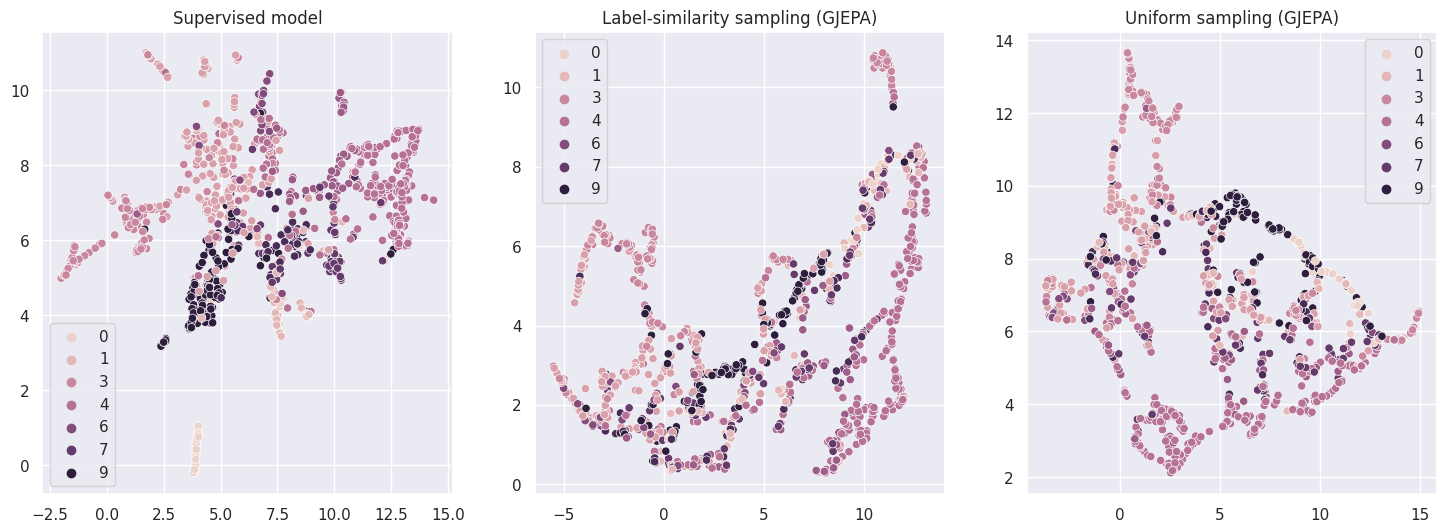

In [16]:
def plot_projs(out, ax, title):
    sns.scatterplot(x=out["proj_z"][:, 0], y=out["proj_z"][:, 1], hue=out["y"], ax=ax)
    ax.set(title=title)
    return ax


fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plot_projs(supervised_out, axes[0], "Supervised model")
plot_projs(label_sim_out, axes[1], "Label-similarity sampling (GJEPA)")
plot_projs(uni_sim_out, axes[2], "Uniform sampling (GJEPA)")
plt.show()